<a href="https://colab.research.google.com/github/ehuangasu/MAT422/blob/main/MAT422_Section_2_4_MLE_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DynamicLLM/MAT422/blob/main/Skills/Student-Home-Work-Skills-Pack/mat422-section-2-4-mle-linear-regression/assets/MAT422_Section_2_4_MLE_Linear_Regression.ipynb)

# MAT 422 - Section 2.4: MLE and Linear Regression

**Topics:** MLE for random samples, Linear regression

> Student note: This Colab badge is required for submission. Create or edit the notebook in Google Colab, then save it directly to GitHub so the badge/icon remains available for grading and reruns.


In [67]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(422)


## MLE for random samples

If we have a bunch of iid samples of a Bernoulli variable, we can calculate the $\hat{p}$ that makes the observed data most likely.

The chance that we see a 1 is $p$, and for a 0 its $1-p$. If there are $k$ 1s and $n$ total samples, the total probability is

$p^k\cdot (1-p)^{n-k}$

Because logarithms are monotonically increasing, maximizing the log probability is equivalent to maximizing the probability. Take the log:

$k\log{(p)}+(n-k)\log{(1-p)}$

This is exactly the `log_likelihood` line in the code below.

To find the maximum, set the derivative to 0:
$\frac{k}{p}-\frac{n-k}{1-p}=0$

$k(1-p)=(n-k)p$

$k=np$

$p=\frac{k}{n}$

The second derivative of the log likelihood is negative (not shown) for $0<p<1$ so this is the global maximum. So the MLE is the sample proportion.

Number of successes = 22
MLE p-hat = 0.55


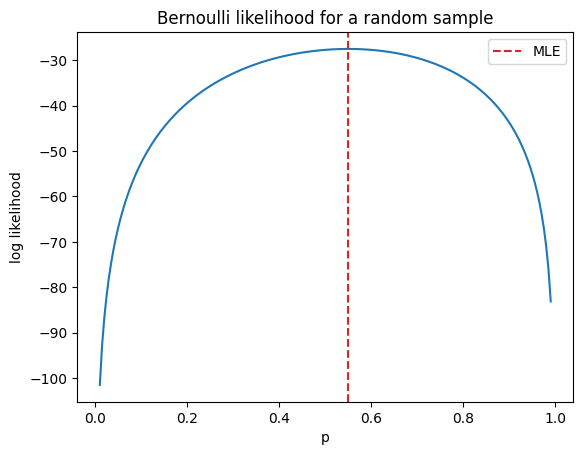

In [68]:
n = 40
true_p = 0.65
sample = rng.binomial(1, true_p, size=n)
p_hat = sample.mean()

grid = np.linspace(0.01, 0.99, 200)
log_likelihood = sample.sum() * np.log(grid) + (n - sample.sum()) * np.log(1 - grid)

print("Number of successes =", sample.sum())
print("MLE p-hat =", p_hat)

plt.plot(grid, log_likelihood)
plt.axvline(p_hat, color="tab:red", linestyle="--", label="MLE")
plt.xlabel("p")
plt.ylabel("log likelihood")
plt.title("Bernoulli likelihood for a random sample")
plt.legend()
plt.show()


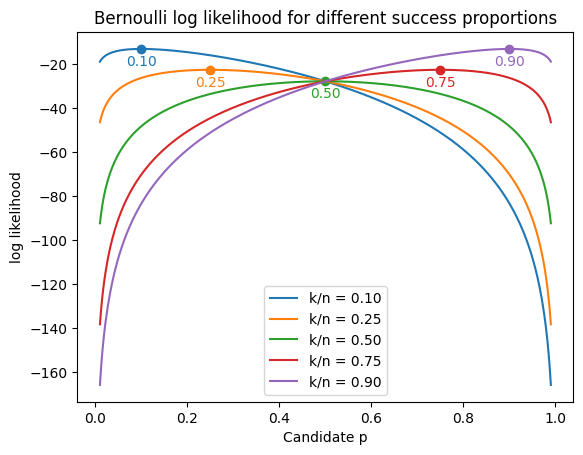

In [69]:
success_counts = [0.1, 0.25, 0.5, 0.75, 0.90]
grid = np.linspace(0.01, 0.99, 400)

for p_hat in success_counts:
    k = p_hat * n
    log_likelihood = k * np.log(grid) + (n - k) * np.log(1 - grid)

    line, = plt.plot(grid, log_likelihood, label=f"k/n = {p_hat:.2f}")

    # Mark the maximum of each curve
    peak = k * np.log(p_hat) + (n - k) * np.log(1 - p_hat)
    plt.scatter(p_hat, peak, color=line.get_color())
    plt.annotate(
        f"{p_hat:.2f}",
        (p_hat, peak),
        xytext=(0, -12),
        textcoords="offset points",
        ha="center",
        color=line.get_color(),
    )

plt.xlabel("Candidate p")
plt.ylabel("log likelihood")
plt.title("Bernoulli log likelihood for different success proportions")
plt.legend()
plt.show()

## Linear regression

Under linear regression, we observe pairs $(x_i,y_i)$ and model

$$y_i=\beta_0+\beta_1x_i+\varepsilon_i$$

Let $f(x_i)=\beta_0+\beta_1x_i$. Least squares chooses $\beta_0,\beta_1$ that minimizes $Σ(y_i-f(x_i))^2$.

We will show that least squares is the MLE assuming the errors are iid and Gaussian.

If errors are from $N(0,\sigma^2)$, each point has probability

$\frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\left(-\frac{(y_i-f(x_i))^2}{2\sigma^2}\right)$.

And the total is the product of the probabilities. We want to maximize this product, and using the log probability trick we maximize the sum of logs of individual probabilities.

$Σ\log(\frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\left(-\frac{(y_i-f(x_i))^2}{2\sigma^2}\right))$

=$Σ\log(\frac{1}{\sqrt{2\pi\sigma^2}})+Σ\log(\exp\!\left(-\frac{(y_i-f(x_i))^2}{2\sigma^2}\right))$

The LHS is constant, so we maximize the RHS (cancel log and exp) and multiply by constant $2σ^2$:

$Σ(-(y_i-f(x_i))^2)$

Maximizing this is equivalent to minimzing the negative, $Σ(y_i-f(x_i)^2)$, which is least squares.

Estimated intercept and slope = [2.545  2.0097]
Residual sum of squares = 43.67411580364504


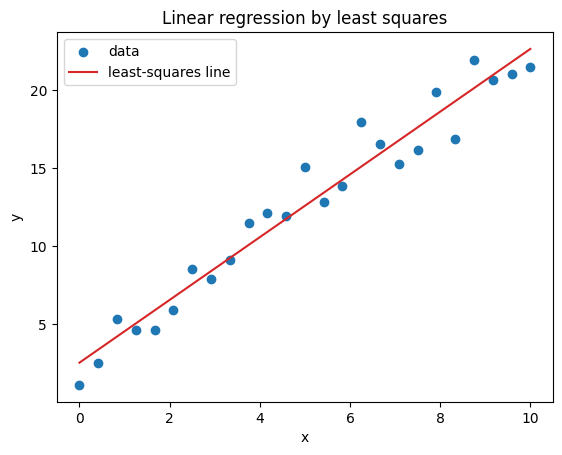

In [70]:
x = np.linspace(0, 10, 25)
y = 1.5 + 2.2 * x + rng.normal(0, 2.0, size=x.size)
X = np.column_stack([np.ones_like(x), x])
beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
y_hat = X @ beta_hat
residuals = y - y_hat

print("Estimated intercept and slope =", beta_hat)
print("Residual sum of squares =", np.sum(residuals ** 2))

plt.scatter(x, y, label="data")
plt.plot(x, y_hat, color="tab:red", label="least-squares line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear regression by least squares")
plt.legend()
plt.show()


We can plot the log-likelihood surface for parameters $\beta_0,\beta_1$ below and check it with the true values (code generated by AI). We also check if the errors are plausibly Gaussian:

Grid peak of l: beta0 = 2.560, beta1 = 2.007  (closed form: [2.545  2.0097])
Residual mean = -1.14e-15, residual SD (MLE) = 1.322


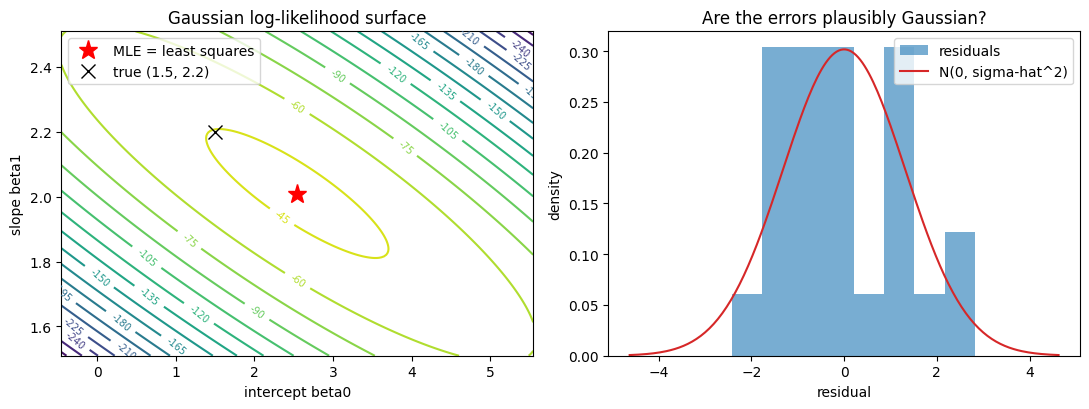

In [71]:
from scipy.optimize import minimize

n_obs = x.size

def negative_log_likelihood(theta):
    b0, b1, log_sigma = theta
    sigma2 = np.exp(2 * log_sigma)
    r = y - (b0 + b1 * x)
    return 0.5 * n_obs * np.log(2 * np.pi * sigma2) + np.sum(r ** 2) / (2 * sigma2)

result = minimize(negative_log_likelihood, x0=np.zeros(3), method="BFGS")
beta_numeric = result.x[:2]
sigma2_numeric = np.exp(2 * result.x[2])

rss = np.sum(residuals ** 2)
sigma2_mle = rss / n_obs
sigma2_unbiased = rss / (n_obs - 2)
max_log_lik_formula = -0.5 * n_obs * (np.log(2 * np.pi * sigma2_mle) + 1)
beta_lstsq = np.linalg.lstsq(X, y, rcond=None)[0]

b0_grid = np.linspace(beta_hat[0] - 3, beta_hat[0] + 3, 200)
b1_grid = np.linspace(beta_hat[1] - 0.5, beta_hat[1] + 0.5, 200)
B0, B1 = np.meshgrid(b0_grid, b1_grid)
rss_surface = ((y[None, None, :] - B0[..., None] - B1[..., None] * x[None, None, :]) ** 2).sum(axis=2)
log_lik_surface = -0.5 * n_obs * np.log(2 * np.pi * sigma2_mle) - rss_surface / (2 * sigma2_mle)

peak = np.unravel_index(np.argmax(log_lik_surface), log_lik_surface.shape)
print(f"Grid peak of l: beta0 = {B0[peak]:.3f}, beta1 = {B1[peak]:.3f}  (closed form: {beta_hat})")
print(f"Residual mean = {residuals.mean():.2e}, residual SD (MLE) = {np.sqrt(sigma2_mle):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
cs = axes[0].contour(B0, B1, log_lik_surface, levels=15, cmap="viridis")
axes[0].clabel(cs, fontsize=7, fmt="%.0f")
axes[0].plot(*beta_hat, "r*", markersize=14, label="MLE = least squares")
axes[0].plot(1.5, 2.2, "kx", markersize=10, label="true (1.5, 2.2)")
axes[0].set(xlabel="intercept beta0", ylabel="slope beta1", title="Gaussian log-likelihood surface")
axes[0].legend()

r_grid = np.linspace(-3.5, 3.5, 200) * np.sqrt(sigma2_mle)
axes[1].hist(residuals, bins=8, density=True, alpha=0.6, label="residuals")
axes[1].plot(r_grid, np.exp(-r_grid ** 2 / (2 * sigma2_mle)) / np.sqrt(2 * np.pi * sigma2_mle),
             color="tab:red", label="N(0, sigma-hat^2)")
axes[1].set(xlabel="residual", ylabel="density", title="Are the errors plausibly Gaussian?")
axes[1].legend()
plt.tight_layout()
plt.show()

## Reflection and Submission Checklist

- I explained each concept in words before or after the code.
- I verified important claims numerically or visually.
- I changed or extended at least one example so the notebook reflects my own work.
- I ran the notebook from top to bottom without errors.
- I saved the notebook from Google Colab directly to GitHub, following the course instructions.
